<a href="https://colab.research.google.com/github/11239A086/OpenCV/blob/master/OpenCV_Exercise12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Experiment 12 : OBJECT DETECTION

Face Detection (Haar Cascade) using

Pre-trained model

Eye Detection
Smile Detection

In [13]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')
smile_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_smile.xml')

Faces detected: 1
Eyes detected: 2
Smiles detected: 0


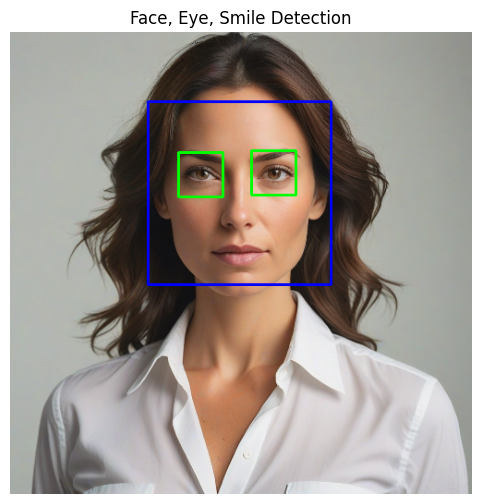

In [16]:
import cv2
import matplotlib.pyplot as plt

# -------- 1. Load Haar Cascade Models --------
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')
smile_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_smile.xml')

# -------- 2. Read Image --------
img = cv2.imread("/content/drive/MyDrive/dataset/face.png")   # make sure this file exists
img = cv2.resize(img, (500, 500))
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# -------- 3. Detect Face --------
faces = face_cascade.detectMultiScale(gray, 1.2, 5)

print("Faces detected:", len(faces))

for (x, y, w, h) in faces:
    cv2.rectangle(img, (x,y), (x+w,y+h), (255,0,0), 2)

    roi_gray = gray[y:y+h, x:x+w]
    roi_color = img[y:y+h, x:x+w]

    # -------- 4. Detect Eyes (Improved) --------
    eyes = eye_cascade.detectMultiScale(roi_gray, 1.2, 15)
    print("Eyes detected:", len(eyes))

    for (ex, ey, ew, eh) in eyes:
        cv2.rectangle(roi_color, (ex,ey), (ex+ew,ey+eh), (0,255,0), 2)

    # -------- 5. Detect Smile (Improved) --------
    smiles = smile_cascade.detectMultiScale(roi_gray, 1.8, 30)
    print("Smiles detected:", len(smiles))

    for (sx, sy, sw, sh) in smiles:
        cv2.rectangle(roi_color, (sx,sy), (sx+sw,sy+sh), (0,0,255), 2)

# -------- 6. Convert for Display --------
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# -------- 7. Show Output --------
plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.title("Face, Eye, Smile Detection")
plt.axis('off')
plt.show()